# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: ANDI BACHDAR DD
- Email: andibahdar44@gmail.com
- Id Dicoding: ANDI BACHDAR DD

## Persiapan
# 🎓 Prediksi Risiko Dropout Mahasiswa  
## Studi Kasus: Jaya Jaya Institut

Dalam beberapa tahun terakhir, Jaya Jaya Institut menghadapi tantangan serius terkait tingginya angka mahasiswa yang tidak menyelesaikan studi (dropout).

Masalah ini tidak hanya berdampak pada reputasi institusi, tetapi juga mencerminkan adanya gap dalam sistem monitoring performa mahasiswa.

Melalui pendekatan data science, proyek ini bertujuan untuk:
- Mengidentifikasi pola performa mahasiswa
- Mendeteksi potensi dropout lebih awal
- Memberikan rekomendasi berbasis data

Pendekatan yang digunakan mencakup eksplorasi data, pemodelan machine learning, serta interpretasi insight untuk kebutuhan bisnis.

### Menyiapkan library yang dibutuhkan
Pada tahap awal, dilakukan import beberapa library utama yang digunakan dalam proses analisis data dan pengembangan model machine learning.

Library yang digunakan mencakup:
- **pandas & numpy** untuk pengolahan data
- **matplotlib & seaborn** untuk visualisasi
- **scikit-learn** untuk preprocessing, modeling, dan evaluasi

Pemilihan library ini didasarkan pada kebutuhan analisis yang bersifat eksploratif sekaligus prediktif.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, auc,
                              confusion_matrix, classification_report)

warnings.filterwarnings('ignore')

## plot style


In [45]:
BG_DARK  = '#0f1117'
CARD_BG  = '#1a1d2e'
PALETTE  = ['#4ade80', '#f87171']

plt.rcParams['figure.facecolor'] = BG_DARK
plt.rcParams['axes.facecolor']   = CARD_BG
plt.rcParams['axes.edgecolor']   = '#3a3f5c'
plt.rcParams['axes.labelcolor']  = '#e0e0e0'
plt.rcParams['xtick.color']      = '#b0b0b0'
plt.rcParams['ytick.color']      = '#b0b0b0'
plt.rcParams['text.color']       = '#e0e0e0'
plt.rcParams['grid.color']       = '#2a2d3e'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.linewidth']   = 0.5

### Menyiapkan data yang akan diguankan

## Data Understanding

In [46]:
df = pd.read_csv('data.csv', sep=';')
print(f'✅ Dataset berhasil dimuat.')
print(f'   Shape: {df.shape}')
print(f'\nDistribusi Status:')
print(df['Status'].value_counts())

✅ Dataset berhasil dimuat.
   Shape: (4424, 37)

Distribusi Status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


### Gambaran Awal Dataset

Dataset berhasil dimuat dengan **4.424 baris** dan **37 kolom**.
Dari distribusi kolom target `Status`, terlihat bahwa mahasiswa terbagi
menjadi tiga kelompok:

- **Graduate**: 2.209 mahasiswa (49.9%) — kelompok terbesar
- **Dropout**: 1.421 mahasiswa (32.1%) — hampir sepertiga dari total
- **Enrolled**: 794 mahasiswa (17.9%) — masih aktif, belum ada label akhir

Angka dropout 32.1% cukup besar dan menjadi fokus utama analisis ini.
"""

## Eksplorasi Data (EDA)

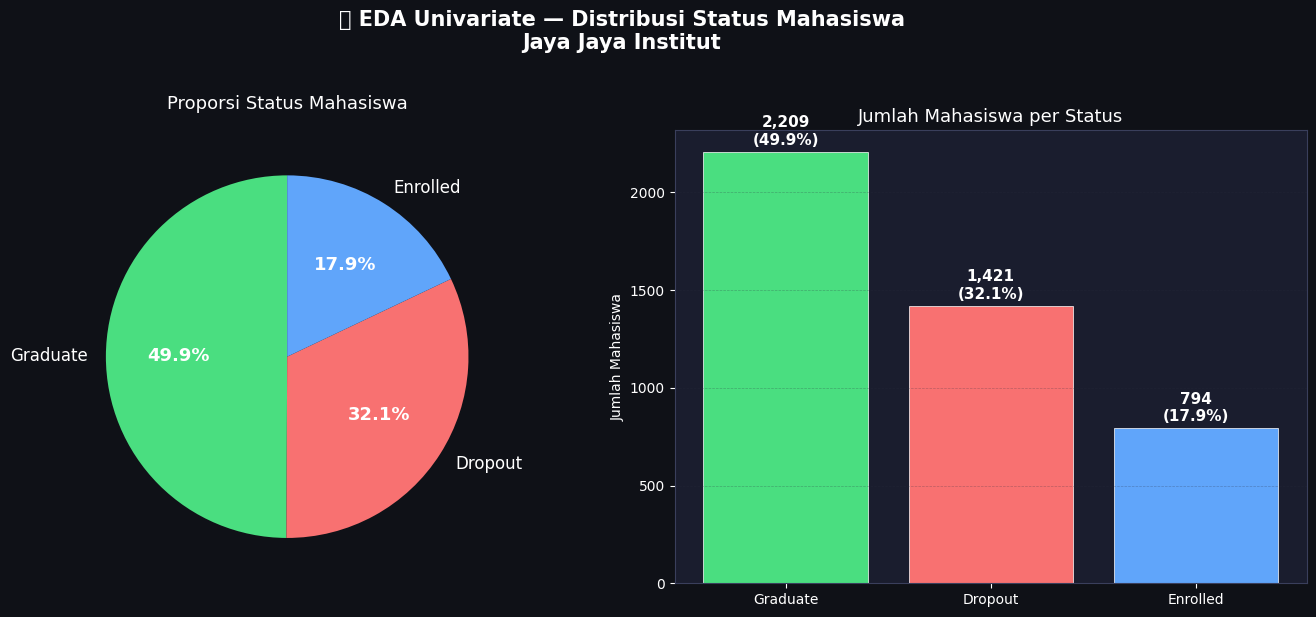


📌 Insight: Dropout rate = 32.1% (1,421 mahasiswa)
   Graduate rate = 49.9% (2,209 mahasiswa)
   Enrolled = 17.9% (794 mahasiswa)


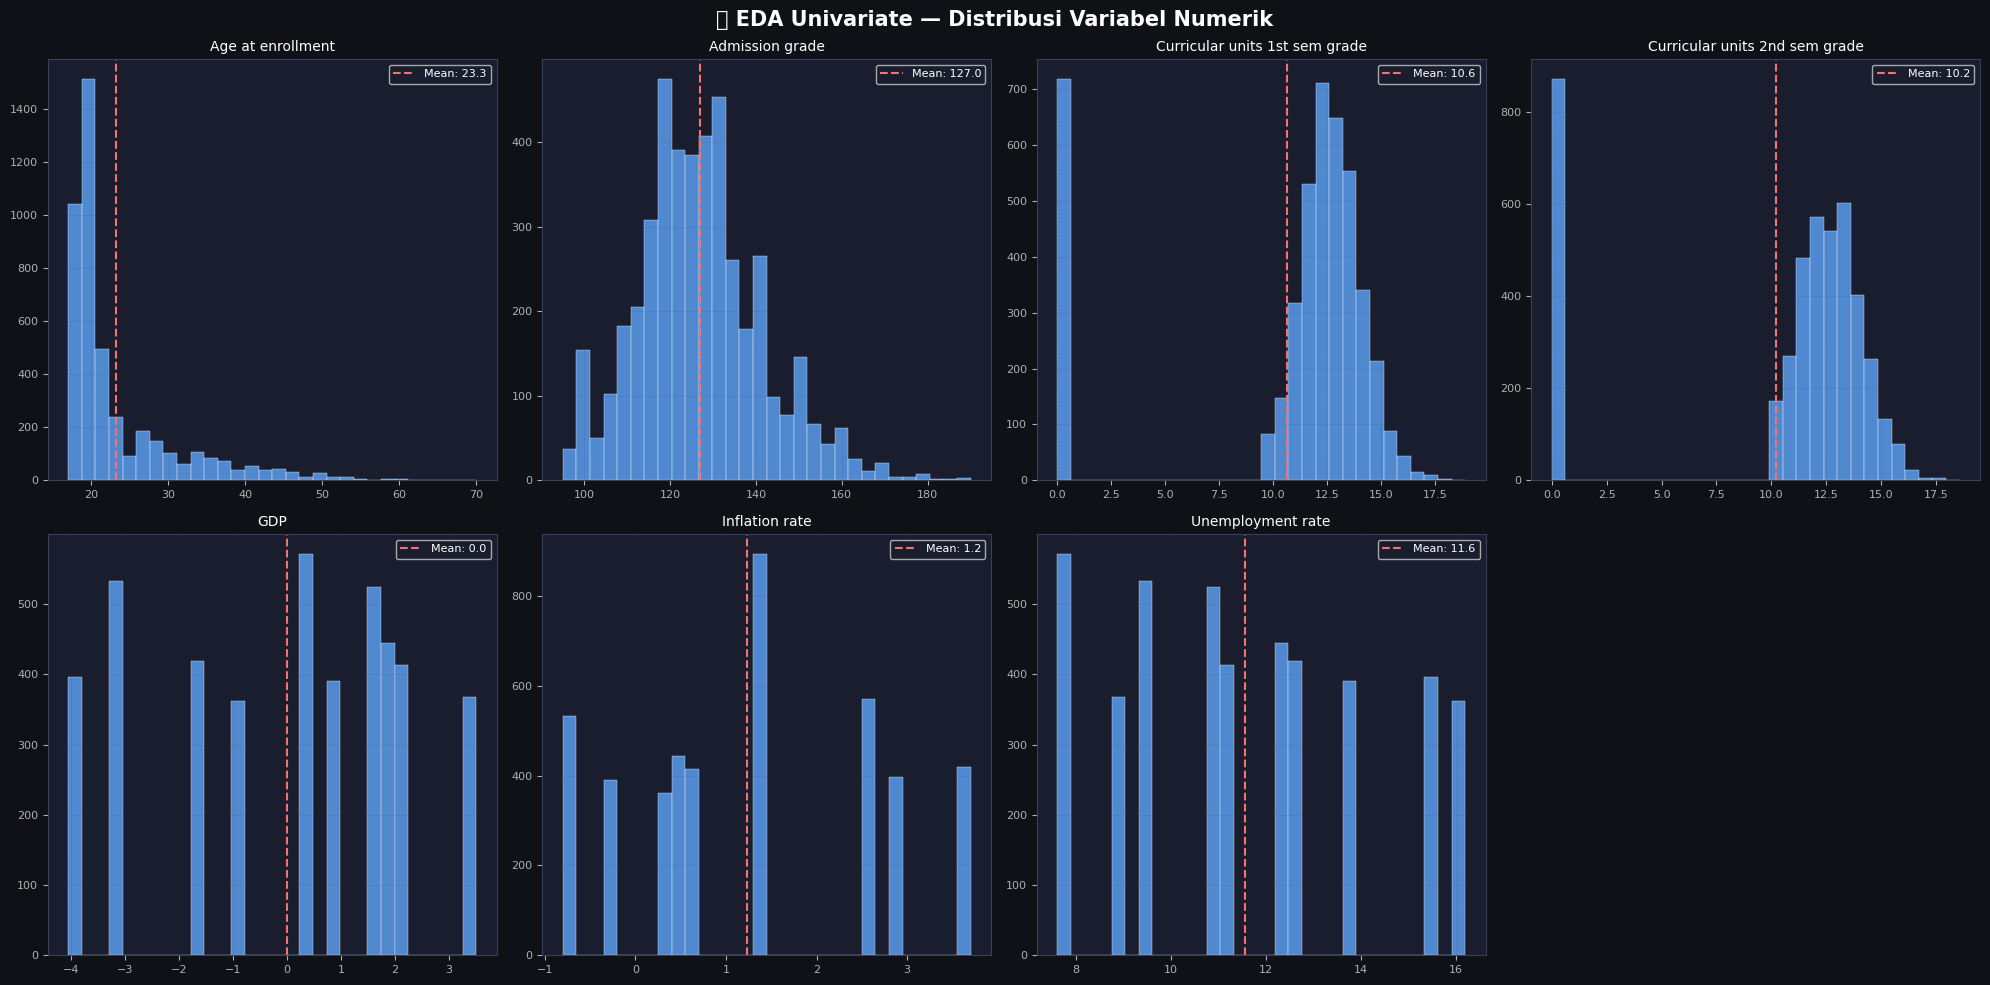

📌 Insight: Distribusi Age_at_enrollment right-skewed — mayoritas mahasiswa berusia 17-23 tahun
   Distribusi nilai semester 1 & 2 menunjukkan banyak mahasiswa dengan nilai 0 (tidak ikut evaluasi)


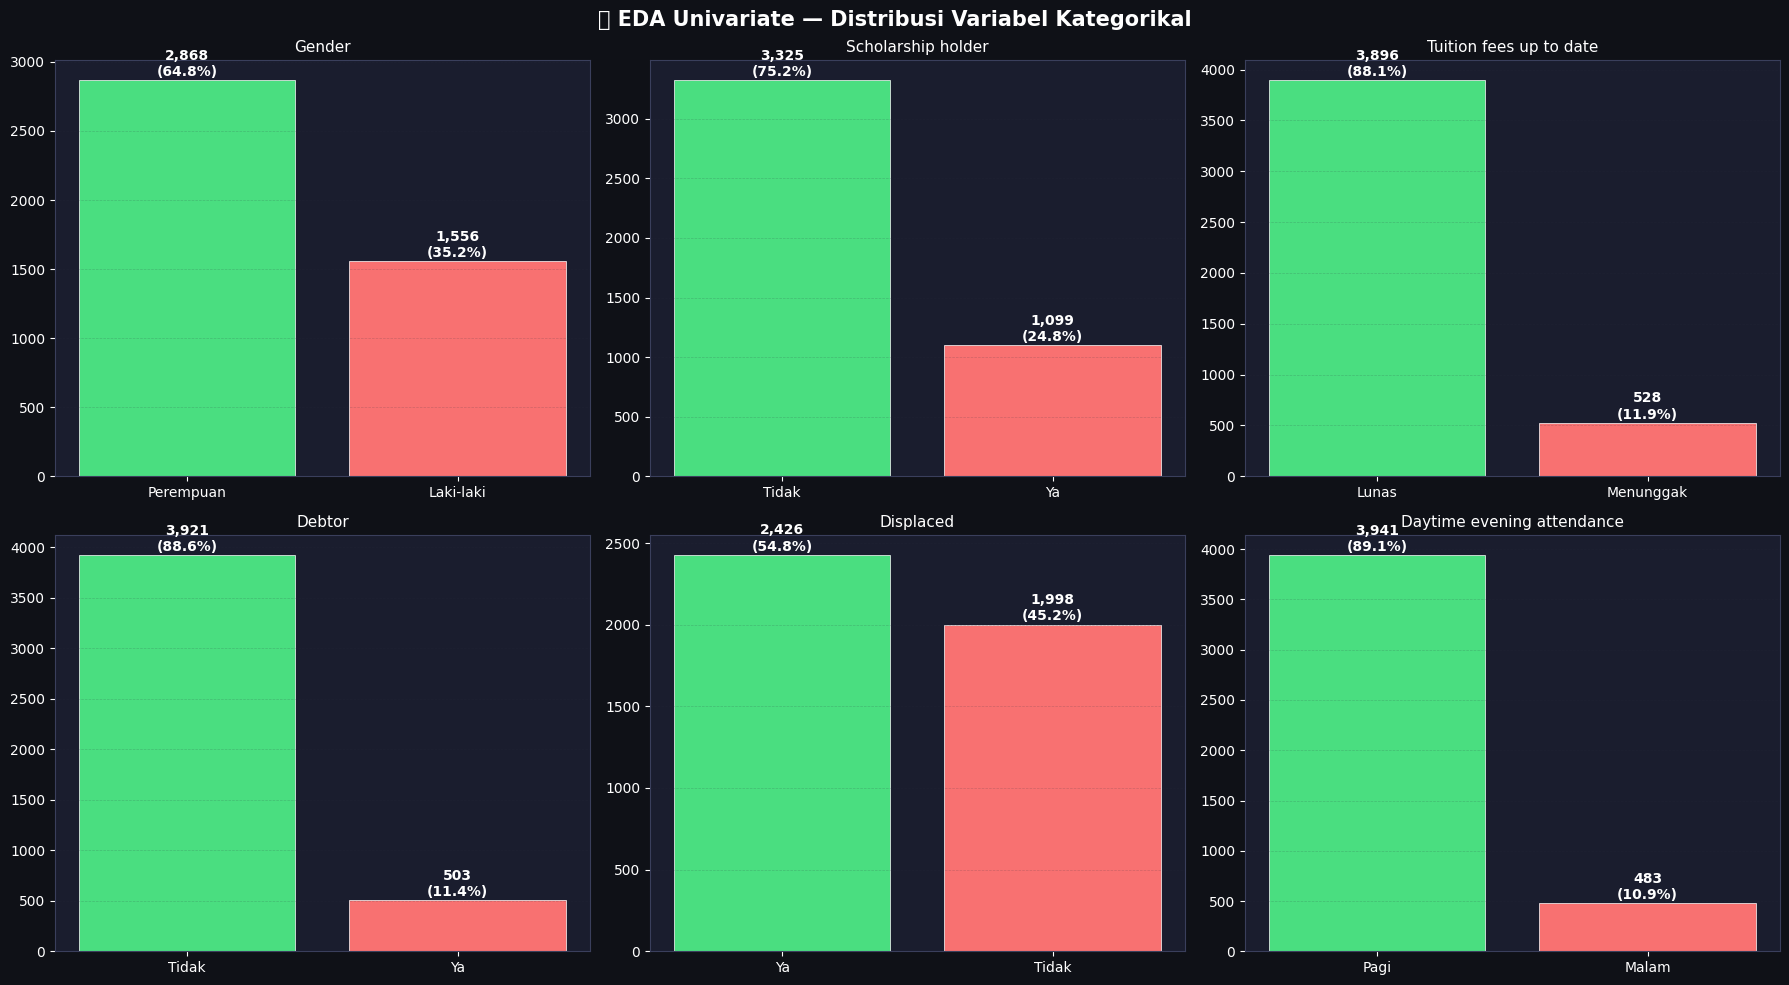

📌 Insight Kategorikal:
   - Gender: {'Perempuan': 2868, 'Laki-laki': 1556}
   - Penerima beasiswa: 1,099 mahasiswa (24.8%)
   - Mahasiswa menunggak SPP: 528 (11.9%)


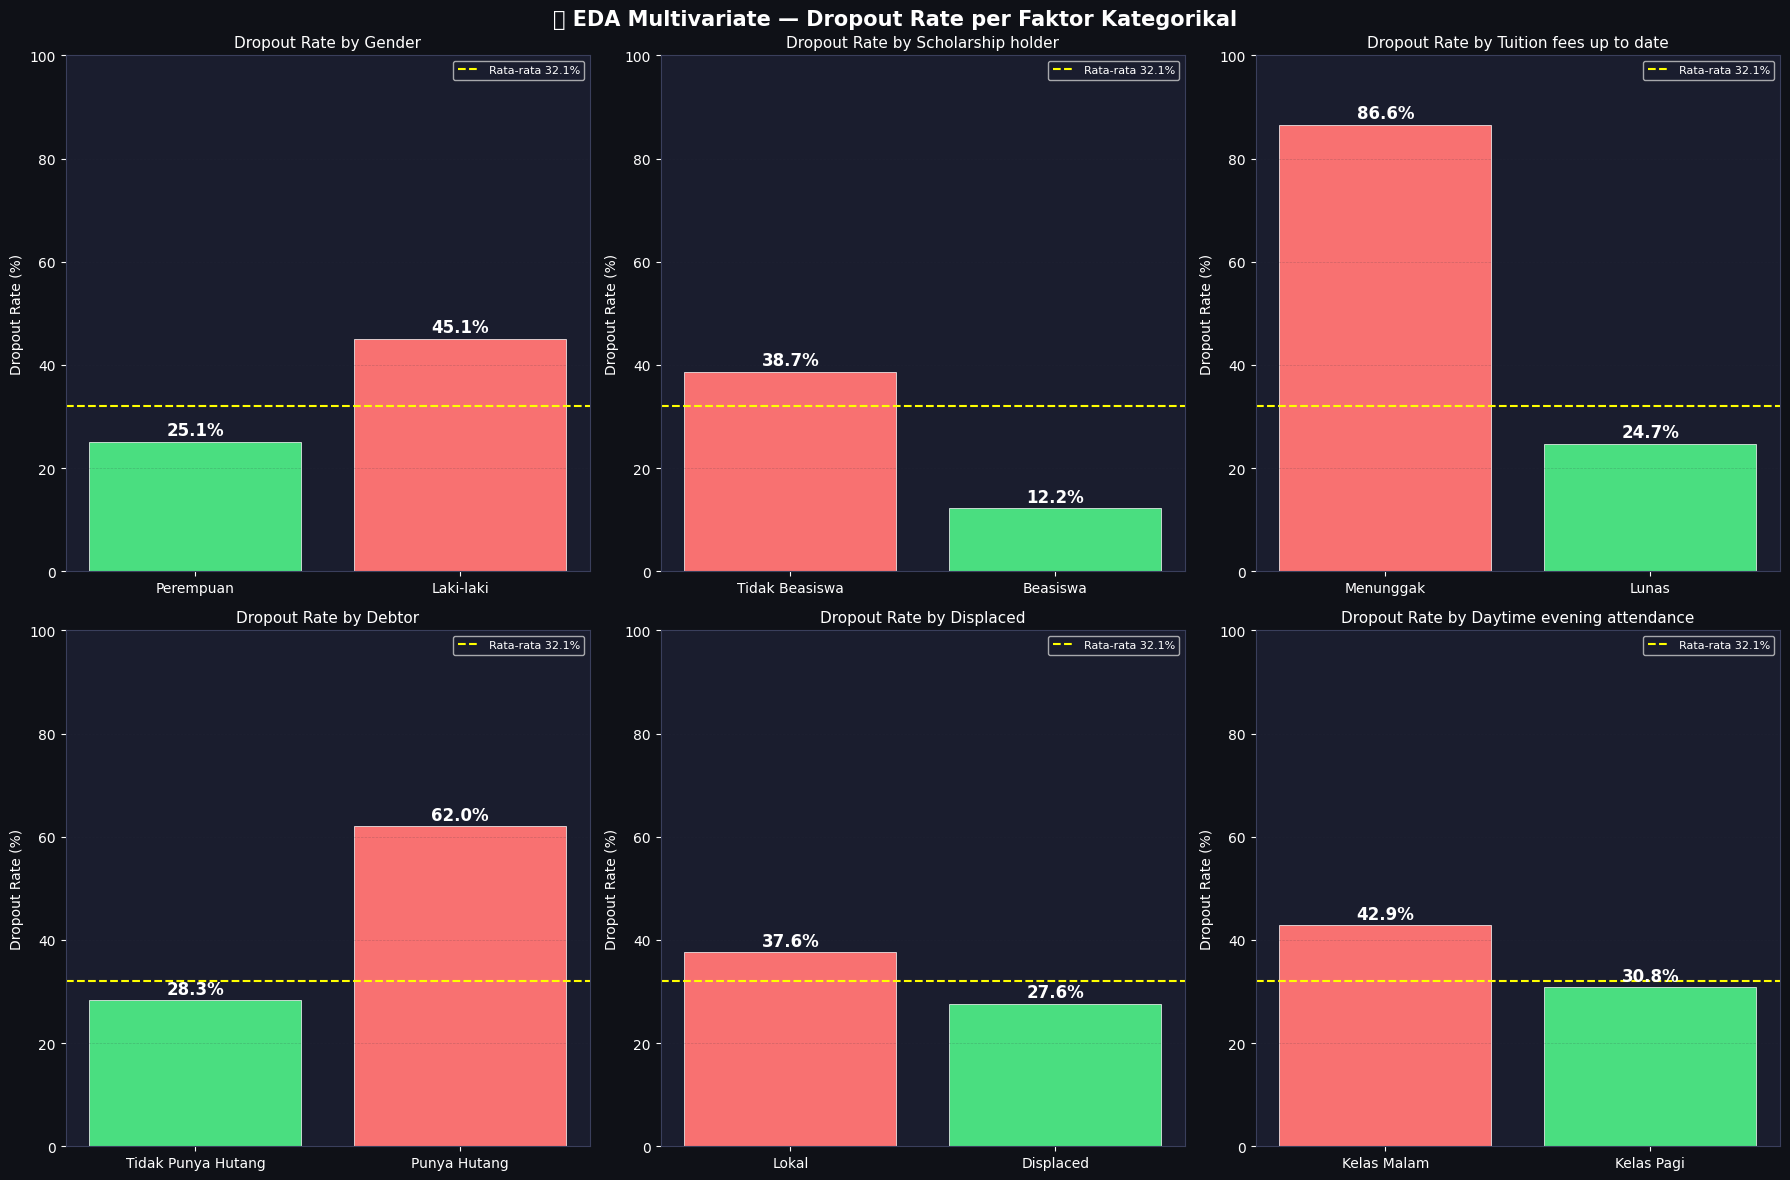

📌 Insight Multivariate:
   - Mahasiswa laki-laki: dropout rate 45.1% vs perempuan 25.1%
   - Tanpa beasiswa: dropout rate 38.7% vs dengan beasiswa 12.2%
   - Menunggak SPP: dropout rate 86.6% vs lunas 24.7%


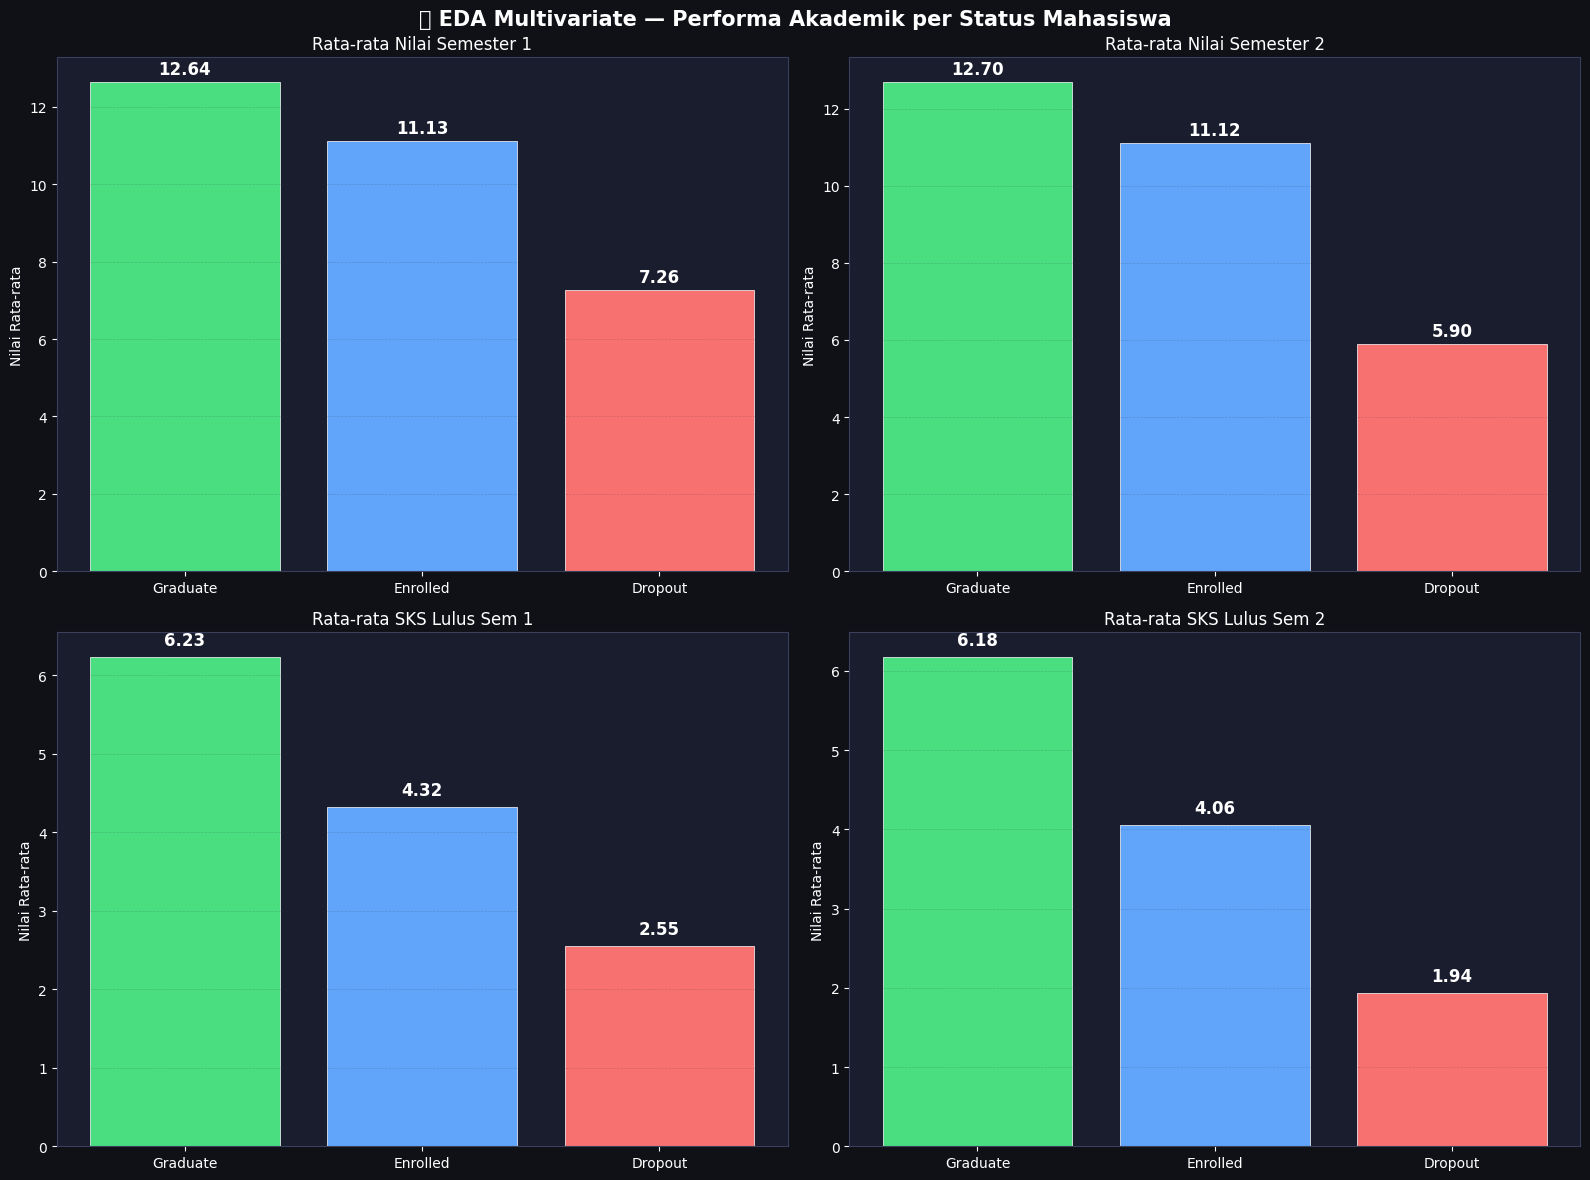

📌 Insight Performa Akademik:

   Rata-rata Nilai Semester 1:
     Graduate: 12.64
     Enrolled: 11.13
     Dropout: 7.26

   Rata-rata Nilai Semester 2:
     Graduate: 12.70
     Enrolled: 11.12
     Dropout: 5.90

   Rata-rata SKS Lulus Sem 1:
     Graduate: 6.23
     Enrolled: 4.32
     Dropout: 2.55

   Rata-rata SKS Lulus Sem 2:
     Graduate: 6.18
     Enrolled: 4.06
     Dropout: 1.94


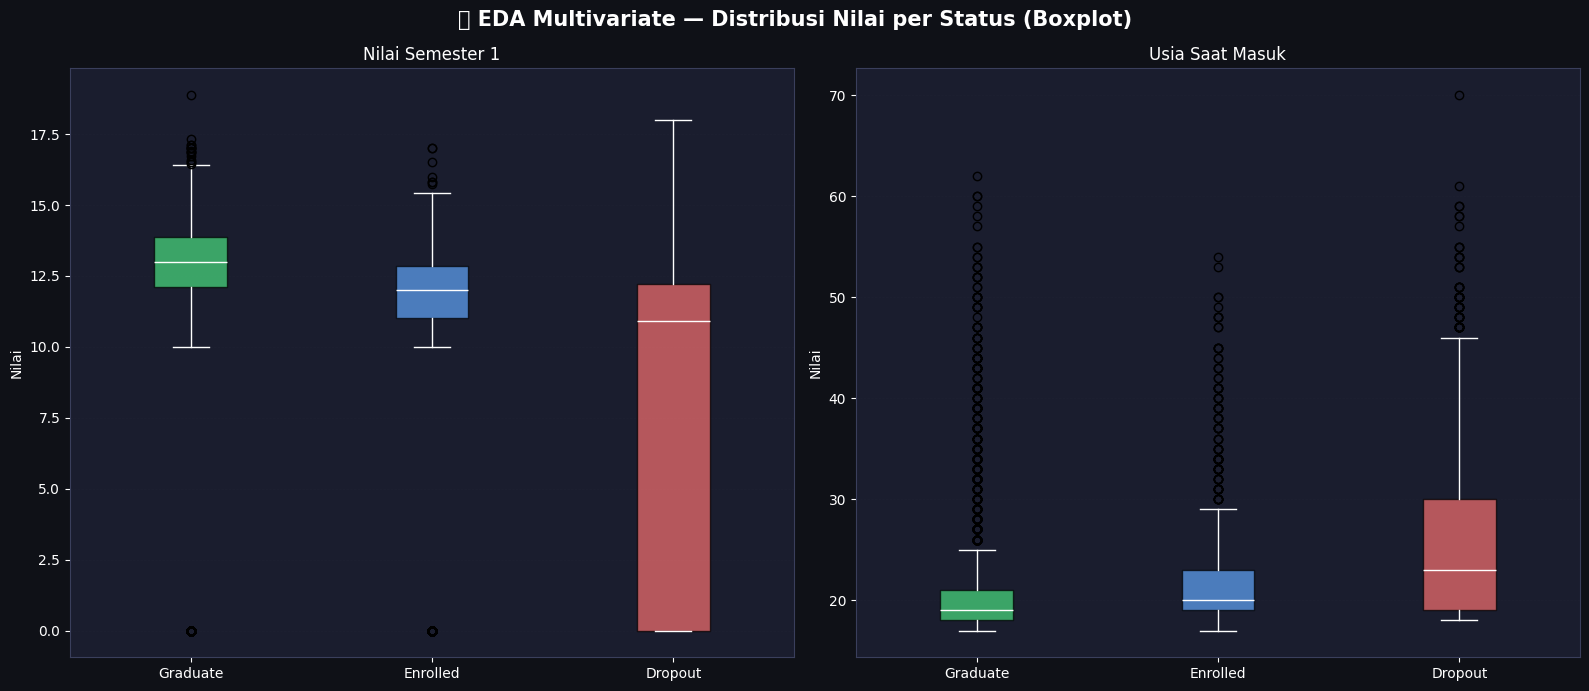

📌 Insight Boxplot:
   - Mahasiswa Dropout memiliki median nilai semester 1 = 0 (tidak ikut evaluasi)
   - Mahasiswa Dropout cenderung berusia lebih tua saat masuk
   - Mahasiswa Graduate memiliki distribusi nilai lebih konsisten dan tinggi


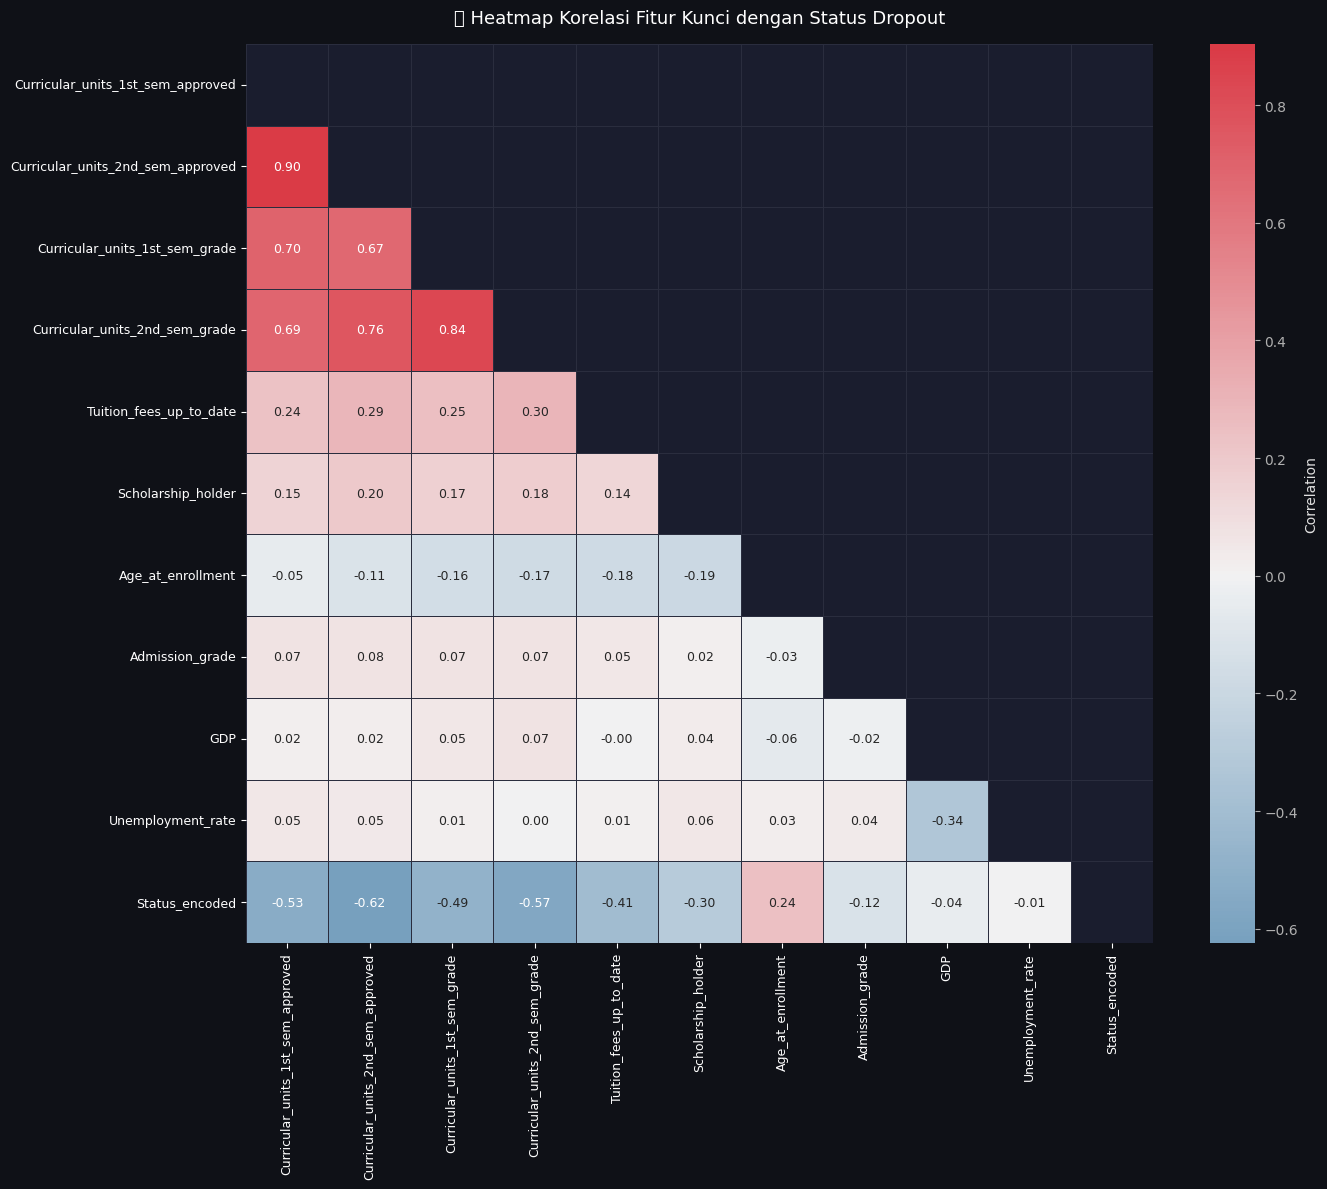

📌 Insight Korelasi:

   Top fitur berkorelasi dengan Status:
   Curricular_units_2nd_sem_approved: -0.624 (↓ risiko dropout)
   Curricular_units_2nd_sem_grade: -0.567 (↓ risiko dropout)
   Curricular_units_1st_sem_approved: -0.529 (↓ risiko dropout)
   Curricular_units_1st_sem_grade: -0.485 (↓ risiko dropout)
   Tuition_fees_up_to_date: -0.410 (↓ risiko dropout)
   Scholarship_holder: -0.298 (↓ risiko dropout)


In [47]:


# ── EDA 1: UNIVARIATE — Distribusi Target (Status) ──────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data.csv', sep=';')

BG_DARK  = '#0f1117'
CARD_BG  = '#1a1d2e'
PALETTE  = ['#4ade80', '#f87171', '#60a5fa']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('📊 EDA Univariate — Distribusi Status Mahasiswa\nJaya Jaya Institut',
             fontsize=15, fontweight='bold', color='white', y=1.02)

counts = df['Status'].value_counts()

# Pie chart
axes[0].set_facecolor(CARD_BG)
wedges, texts, autotexts = axes[0].pie(
    counts.values, labels=counts.index,
    colors=PALETTE, autopct='%1.1f%%',
    startangle=90, textprops={'color': 'white', 'fontsize': 12}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[0].set_title('Proporsi Status Mahasiswa', color='white', fontsize=13, pad=15)

# Bar chart
axes[1].set_facecolor(CARD_BG)
bars = axes[1].bar(counts.index, counts.values, color=PALETTE, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', color='white', fontsize=11, fontweight='bold')
axes[1].set_title('Jumlah Mahasiswa per Status', color='white', fontsize=13)
axes[1].set_ylabel('Jumlah Mahasiswa', color='white')
axes[1].tick_params(colors='white')
axes[1].set_facecolor(CARD_BG)
for spine in axes[1].spines.values():
    spine.set_color('#3a3f5c')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_status_distribution.png', dpi=150, bbox_inches='tight',
            facecolor=BG_DARK)
plt.show()
print(f"\n📌 Insight: Dropout rate = {counts['Dropout']/len(df)*100:.1f}% ({counts['Dropout']:,} mahasiswa)")
print(f"   Graduate rate = {counts['Graduate']/len(df)*100:.1f}% ({counts['Graduate']:,} mahasiswa)")
print(f"   Enrolled = {counts['Enrolled']/len(df)*100:.1f}% ({counts['Enrolled']:,} mahasiswa)")


# ── EDA 2: UNIVARIATE — Distribusi Variabel Numerik ─────────────────────────
num_cols = ['Age_at_enrollment', 'Admission_grade',
            'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
            'GDP', 'Inflation_rate', 'Unemployment_rate']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('📈 EDA Univariate — Distribusi Variabel Numerik',
             fontsize=15, fontweight='bold', color='white')

axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].set_facecolor(CARD_BG)
    axes[i].hist(df[col], bins=30, color='#60a5fa', edgecolor='white', alpha=0.8, linewidth=0.3)
    axes[i].set_title(col.replace('_', ' '), color='white', fontsize=10)
    axes[i].tick_params(colors='#b0b0b0', labelsize=8)
    for spine in axes[i].spines.values():
        spine.set_color('#3a3f5c')
    axes[i].grid(alpha=0.2)
    mean_val = df[col].mean()
    axes[i].axvline(mean_val, color='#f87171', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].legend(fontsize=8, labelcolor='white', facecolor=CARD_BG)

# Hide last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('eda_numeric_dist.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print("📌 Insight: Distribusi Age_at_enrollment right-skewed — mayoritas mahasiswa berusia 17-23 tahun")
print("   Distribusi nilai semester 1 & 2 menunjukkan banyak mahasiswa dengan nilai 0 (tidak ikut evaluasi)")


# ── EDA 3: UNIVARIATE — Distribusi Variabel Kategorikal ─────────────────────
cat_binary = {
    'Gender': {0: 'Perempuan', 1: 'Laki-laki'},
    'Scholarship_holder': {0: 'Tidak', 1: 'Ya'},
    'Tuition_fees_up_to_date': {0: 'Menunggak', 1: 'Lunas'},
    'Debtor': {0: 'Tidak', 1: 'Ya'},
    'Displaced': {0: 'Tidak', 1: 'Ya'},
    'Daytime_evening_attendance': {0: 'Malam', 1: 'Pagi'}
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('📊 EDA Univariate — Distribusi Variabel Kategorikal',
             fontsize=15, fontweight='bold', color='white')
axes = axes.flatten()

for i, (col, label_map) in enumerate(cat_binary.items()):
    axes[i].set_facecolor(CARD_BG)
    counts_col = df[col].map(label_map).value_counts()
    bars = axes[i].bar(counts_col.index, counts_col.values,
                       color=['#4ade80', '#f87171'], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, counts_col.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                     f'{val:,}\n({val/len(df)*100:.1f}%)',
                     ha='center', va='bottom', color='white', fontsize=10, fontweight='bold')
    axes[i].set_title(col.replace('_', ' '), color='white', fontsize=11)
    axes[i].tick_params(colors='white')
    for spine in axes[i].spines.values():
        spine.set_color('#3a3f5c')
    axes[i].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('eda_categorical_dist.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print("📌 Insight Kategorikal:")
print(f"   - Gender: {df['Gender'].map({0:'Perempuan',1:'Laki-laki'}).value_counts().to_dict()}")
print(f"   - Penerima beasiswa: {df['Scholarship_holder'].sum():,} mahasiswa ({df['Scholarship_holder'].mean()*100:.1f}%)")
print(f"   - Mahasiswa menunggak SPP: {(df['Tuition_fees_up_to_date']==0).sum():,} ({(df['Tuition_fees_up_to_date']==0).mean()*100:.1f}%)")


# ── EDA 4: MULTIVARIATE — Dropout Rate per Faktor ───────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('🔍 EDA Multivariate — Dropout Rate per Faktor Kategorikal',
             fontsize=15, fontweight='bold', color='white')
axes = axes.flatten()

factors = [
    ('Gender', {0: 'Perempuan', 1: 'Laki-laki'}),
    ('Scholarship_holder', {0: 'Tidak Beasiswa', 1: 'Beasiswa'}),
    ('Tuition_fees_up_to_date', {0: 'Menunggak', 1: 'Lunas'}),
    ('Debtor', {0: 'Tidak Punya Hutang', 1: 'Punya Hutang'}),
    ('Displaced', {0: 'Lokal', 1: 'Displaced'}),
    ('Daytime_evening_attendance', {0: 'Kelas Malam', 1: 'Kelas Pagi'}),
]

df_temp = df.copy()
df_temp['is_dropout'] = (df_temp['Status'] == 'Dropout').astype(int)

for i, (col, label_map) in enumerate(factors):
    axes[i].set_facecolor(CARD_BG)
    dropout_rate = df_temp.groupby(col)['is_dropout'].mean() * 100
    dropout_rate.index = dropout_rate.index.map(label_map)

    colors_bar = ['#4ade80' if v < 35 else '#f87171' for v in dropout_rate.values]
    bars = axes[i].bar(dropout_rate.index, dropout_rate.values,
                       color=colors_bar, edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, dropout_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom',
                     color='white', fontsize=12, fontweight='bold')
    axes[i].set_title(f'Dropout Rate by {col.replace("_"," ")}',
                      color='white', fontsize=11)
    axes[i].set_ylabel('Dropout Rate (%)', color='white')
    axes[i].tick_params(colors='white')
    for spine in axes[i].spines.values():
        spine.set_color('#3a3f5c')
    axes[i].grid(axis='y', alpha=0.2)
    axes[i].set_ylim(0, 100)
    axes[i].axhline(32.1, color='yellow', linestyle='--', linewidth=1.5,
                    label=f'Rata-rata 32.1%')
    axes[i].legend(fontsize=8, labelcolor='white', facecolor=CARD_BG)

plt.tight_layout()
plt.savefig('eda_dropout_by_factor.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

print("📌 Insight Multivariate:")
print(f"   - Mahasiswa laki-laki: dropout rate 45.1% vs perempuan 25.1%")
print(f"   - Tanpa beasiswa: dropout rate 38.7% vs dengan beasiswa 12.2%")
print(f"   - Menunggak SPP: dropout rate 86.6% vs lunas 24.7%")


# ── EDA 5: MULTIVARIATE — Performa Akademik per Status ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('🎓 EDA Multivariate — Performa Akademik per Status Mahasiswa',
             fontsize=15, fontweight='bold', color='white')

academic_metrics = [
    ('Curricular_units_1st_sem_grade', 'Rata-rata Nilai Semester 1'),
    ('Curricular_units_2nd_sem_grade', 'Rata-rata Nilai Semester 2'),
    ('Curricular_units_1st_sem_approved', 'Rata-rata SKS Lulus Sem 1'),
    ('Curricular_units_2nd_sem_approved', 'Rata-rata SKS Lulus Sem 2'),
]

status_order = ['Graduate', 'Enrolled', 'Dropout']
colors_status = ['#4ade80', '#60a5fa', '#f87171']

for i, (col, title) in enumerate(academic_metrics):
    ax = axes[i//2][i%2]
    ax.set_facecolor(CARD_BG)

    means = df.groupby('Status')[col].mean().reindex(status_order)
    bars = ax.bar(means.index, means.values, color=colors_status,
                  edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f}', ha='center', va='bottom',
                color='white', fontsize=12, fontweight='bold')
    ax.set_title(title, color='white', fontsize=12)
    ax.set_ylabel('Nilai Rata-rata', color='white')
    ax.tick_params(colors='white')
    for spine in ax.spines.values():
        spine.set_color('#3a3f5c')
    ax.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('eda_academic_performance.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

print("📌 Insight Performa Akademik:")
for col, title in academic_metrics:
    means = df.groupby('Status')[col].mean()
    print(f"\n   {title}:")
    for status in status_order:
        print(f"     {status}: {means[status]:.2f}")


# ── EDA 6: MULTIVARIATE — Boxplot Distribusi Nilai per Status ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('📦 EDA Multivariate — Distribusi Nilai per Status (Boxplot)',
             fontsize=15, fontweight='bold', color='white')

for i, (col, title) in enumerate([
    ('Curricular_units_1st_sem_grade', 'Nilai Semester 1'),
    ('Age_at_enrollment', 'Usia Saat Masuk')
]):
    axes[i].set_facecolor(CARD_BG)
    data_by_status = [df[df['Status'] == s][col].values for s in status_order]
    bp = axes[i].boxplot(data_by_status, labels=status_order,
                         patch_artist=True, notch=False)
    for patch, color in zip(bp['boxes'], colors_status):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    for element in ['whiskers', 'caps', 'medians', 'fliers']:
        plt.setp(bp[element], color='white')
    axes[i].set_title(title, color='white', fontsize=12)
    axes[i].set_ylabel('Nilai', color='white')
    axes[i].tick_params(colors='white')
    for spine in axes[i].spines.values():
        spine.set_color('#3a3f5c')
    axes[i].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

print("📌 Insight Boxplot:")
print("   - Mahasiswa Dropout memiliki median nilai semester 1 = 0 (tidak ikut evaluasi)")
print("   - Mahasiswa Dropout cenderung berusia lebih tua saat masuk")
print("   - Mahasiswa Graduate memiliki distribusi nilai lebih konsisten dan tinggi")


# ── EDA 7: MULTIVARIATE — Heatmap Korelasi (Numerik) ────────────────────────
df_corr = df.copy()
df_corr['Status_encoded'] = df_corr['Status'].map({'Graduate': 0, 'Enrolled': 1, 'Dropout': 2})

key_features = [
    'Curricular_units_1st_sem_approved', 'Curricular_units_2nd_sem_approved',
    'Curricular_units_1st_sem_grade', 'Curricular_units_2nd_sem_grade',
    'Tuition_fees_up_to_date', 'Scholarship_holder',
    'Age_at_enrollment', 'Admission_grade',
    'GDP', 'Unemployment_rate', 'Status_encoded'
]

fig, ax = plt.subplots(figsize=(14, 12))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(CARD_BG)

corr = df_corr[key_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(240, 10, as_cmap=True)

sns.heatmap(corr, mask=mask, cmap=cmap, center=0,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            linewidths=0.5, linecolor='#2a2d3e',
            cbar_kws={'label': 'Correlation'},
            ax=ax)

ax.set_title('🔗 Heatmap Korelasi Fitur Kunci dengan Status Dropout',
             color='white', fontsize=13, pad=15)
ax.tick_params(colors='white', labelsize=9)

plt.tight_layout()
plt.savefig('eda_heatmap_key.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

print("📌 Insight Korelasi:")
corr_target = corr['Status_encoded'].drop('Status_encoded').sort_values(key=abs, ascending=False)
print("\n   Top fitur berkorelasi dengan Status:")
for feat, val in corr_target.head(6).items():
    direction = "↑ risiko dropout" if val > 0 else "↓ risiko dropout"
    print(f"   {feat}: {val:.3f} ({direction})")

"""
### Temuan dari Eksplorasi Data (EDA)

**Distribusi Status Mahasiswa**
Dari 4.424 mahasiswa, hampir separuh berhasil lulus (49.9%). Namun angka
dropout sebesar 32.1% — hampir 1 dari 3 mahasiswa — menunjukkan bahwa
masalah ini cukup serius dan perlu penanganan berbasis data.

**Distribusi Variabel Numerik**
Distribusi usia saat masuk (*Age_at_enrollment*) bersifat *right-skewed*,
artinya sebagian besar mahasiswa mendaftar di usia 17–23 tahun.
Yang menarik, distribusi nilai semester 1 dan 2 memperlihatkan banyak
mahasiswa dengan nilai 0 — ini bukan berarti nilainya nol, melainkan
mahasiswa tersebut **tidak mengikuti evaluasi sama sekali**, yang merupakan
sinyal awal kemungkinan dropout.

**Distribusi Variabel Kategorikal**
Komposisi gender didominasi perempuan (2.868 mahasiswa, 64.8%) dibanding
laki-laki (1.556 mahasiswa, 35.2%). Hanya 24.8% (1.099 mahasiswa) yang
menerima beasiswa. Meski mahasiswa yang menunggak SPP tergolong minoritas
(528 orang, 11.9%), kelompok ini terbukti memiliki risiko dropout yang
sangat ekstrem seperti yang terlihat pada analisis berikutnya.

**Dropout Rate per Faktor**
Tiga faktor menunjukkan perbedaan dropout rate yang sangat mencolok:

- **Gender**: laki-laki memiliki dropout rate 45.1%, hampir dua kali lipat
  dibanding perempuan 25.1%
- **Beasiswa**: tanpa beasiswa dropout rate 38.7%, sedangkan penerima
  beasiswa hanya 12.2%
- **Status SPP**: mahasiswa yang menunggak memiliki dropout rate 86.6%,
  jauh di atas yang membayar tepat waktu (24.7%)

**Performa Akademik per Status**
Perbedaan performa antar kelompok sangat signifikan. Mahasiswa Graduate
rata-rata lulus 6.23 SKS di semester 1 dan memiliki nilai 12.64, sedangkan
mahasiswa Dropout hanya lulus 2.55 SKS dengan nilai rata-rata 7.26.
Kesenjangan ini bahkan makin lebar di semester 2 — nilai dropout turun ke
5.90 sementara Graduate tetap stabil di 12.70. Pola memburuk ini
mengisyaratkan bahwa intervensi paling efektif adalah di awal semester 2.

**Korelasi Fitur dengan Status**
Semua fitur teratas berkorelasi negatif dengan risiko dropout — artinya
semakin tinggi nilainya, semakin kecil kemungkinan mahasiswa tersebut
dropout. Fitur paling kuat adalah jumlah SKS lulus semester 2 (r = -0.624),
diikuti nilai semester 2 (r = -0.567), SKS lulus semester 1 (r = -0.529),
dan nilai semester 1 (r = -0.485). Status pembayaran SPP (r = -0.410) dan
kepemilikan beasiswa (r = -0.298) juga berkontribusi signifikan.
"""


## Data Preparation / Preprocessing

In [48]:
# Cek missing values
missing = df.isnull().sum().sum()
print(f'\n✅ Missing values: {missing}')

# Cek duplikasi
dupes = df.duplicated().sum()
print(f'✅ Duplikasi: {dupes}')

# Pisahkan data Enrolled untuk inferensi nanti
df_enrolled = df[df['Status'] == 'Enrolled'].copy()
print(f'\n📌 Data Enrolled (untuk inferensi): {len(df_enrolled)} baris')

# Filter hanya Dropout dan Graduate untuk training
df_model = df[df['Status'].isin(['Dropout', 'Graduate'])].copy()
print(f'📌 Data untuk modeling (Dropout + Graduate): {len(df_model)} baris')
print(f'\nDistribusi target setelah filter:')
print(df_model['Status'].value_counts())

# Encode target: Dropout = 1, Graduate = 0
df_model['Status_binary'] = (df_model['Status'] == 'Dropout').astype(int)
print(f'\nEncoding: Dropout=1, Graduate=0')
print(df_model['Status_binary'].value_counts())

# Features dan Target
X = df_model.drop(columns=['Status', 'Status_binary'])
y = df_model['Status_binary']

# Split data (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\n✅ Data splitting selesai:')
print(f'   X_train: {X_train.shape}')
print(f'   X_test : {X_test.shape}')

# Scaling untuk Logistic Regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)


✅ Missing values: 0
✅ Duplikasi: 0

📌 Data Enrolled (untuk inferensi): 794 baris
📌 Data untuk modeling (Dropout + Graduate): 3630 baris

Distribusi target setelah filter:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Encoding: Dropout=1, Graduate=0
Status_binary
0    2209
1    1421
Name: count, dtype: int64

✅ Data splitting selesai:
   X_train: (2904, 36)
   X_test : (726, 36)


"""
### Hasil Preprocessing

Tidak ditemukan missing values maupun duplikasi pada dataset.
Data dalam kondisi bersih sehingga bisa langsung digunakan untuk modeling.

Untuk modeling, data dipilah berdasarkan status:
- **Data latih**: 3.630 baris (Dropout + Graduate saja)
- **Data inferensi**: 794 baris (Enrolled, untuk prediksi nanti)

Alasan pemisahan ini adalah karena mahasiswa Enrolled belum memiliki label
akhir, sehingga menyertakan mereka dalam training akan membuat target
menjadi ambigu dan mengurangi validitas model.

Setelah split 80:20 dengan stratifikasi:
- Data latih: 2.904 baris
- Data uji: 726 baris
"""

# Modeling

# Modeling — Logistic Regression (Baseline)

In [49]:
print('\n' + '='*50)
print('MODEL 1: Logistic Regression (Baseline)')
print('='*50)

lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

acc_lr  = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr, zero_division=0)
rec_lr  = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr   = f1_score(y_test, y_pred_lr, zero_division=0)
auc_lr  = roc_auc_score(y_test, lr.predict_proba(X_test_sc)[:,1])

print(f'Accuracy  : {acc_lr:.4f}')
print(f'Precision : {prec_lr:.4f}')
print(f'Recall    : {rec_lr:.4f}')
print(f'F1 Score  : {f1_lr:.4f}')
print(f'AUC-ROC   : {auc_lr:.4f}')


MODEL 1: Logistic Regression (Baseline)
Accuracy  : 0.9421
Precision : 0.9321
Recall    : 0.9190
F1 Score  : 0.9255
AUC-ROC   : 0.9733


### Logistic Regression — Baseline

Model baseline Logistic Regression sudah menunjukkan performa yang cukup
tinggi sejak awal:

- **Accuracy 94.2%** — model benar memprediksi 9 dari 10 mahasiswa
- **Precision 93.2%** — ketika model memprediksi Dropout, 93.2% benar
- **Recall 91.9%** — model berhasil mendeteksi 91.9% dari semua kasus Dropout
- **AUC 0.9733** — kemampuan diskriminasi model sangat baik

Performa setinggi ini terjadi karena pemisahan data Enrolled dari training
membuat batas keputusan antara Dropout dan Graduate menjadi lebih jelas
bagi model.

# Modeling — Random Forest (Baseline)

In [50]:
print('\n' + '='*50)
print('MODEL 2: Random Forest (Baseline)')
print('='*50)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf, zero_division=0)
rec_rf  = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf   = f1_score(y_test, y_pred_rf, zero_division=0)
auc_rf  = roc_auc_score(y_test, rf.predict_proba(X_test)[:,1])

print(f'Accuracy  : {acc_rf:.4f}')
print(f'Precision : {prec_rf:.4f}')
print(f'Recall    : {rec_rf:.4f}')
print(f'F1 Score  : {f1_rf:.4f}')
print(f'AUC-ROC   : {auc_rf:.4f}')

print('\n=== Classification Report Random Forest ===')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Graduate (0)', 'Dropout (1)']))


MODEL 2: Random Forest (Baseline)
Accuracy  : 0.9215
Precision : 0.9158
Recall    : 0.8803
F1 Score  : 0.8977
AUC-ROC   : 0.9706

=== Classification Report Random Forest ===
              precision    recall  f1-score   support

Graduate (0)       0.92      0.95      0.94       442
 Dropout (1)       0.92      0.88      0.90       284

    accuracy                           0.92       726
   macro avg       0.92      0.91      0.92       726
weighted avg       0.92      0.92      0.92       726



### Random Forest — Baseline

Random Forest baseline memberikan performa yang sedikit di bawah
Logistic Regression pada dataset ini:

- **Accuracy 92.2%** — tetap tinggi, namun 2 poin di bawah LR
- **Recall 88.0%** untuk kelas Dropout — lebih rendah dari LR (91.9%)
- **AUC 0.9706** — sangat baik, meski tipis di bawah LR

Dari classification report terlihat bahwa Random Forest lebih baik
memprediksi Graduate (recall 95%) dibanding Dropout (recall 88%).
Ini wajar karena data Graduate lebih banyak (442 vs 284 di test set).
"""

#  Visualisasi Confusion Matrix

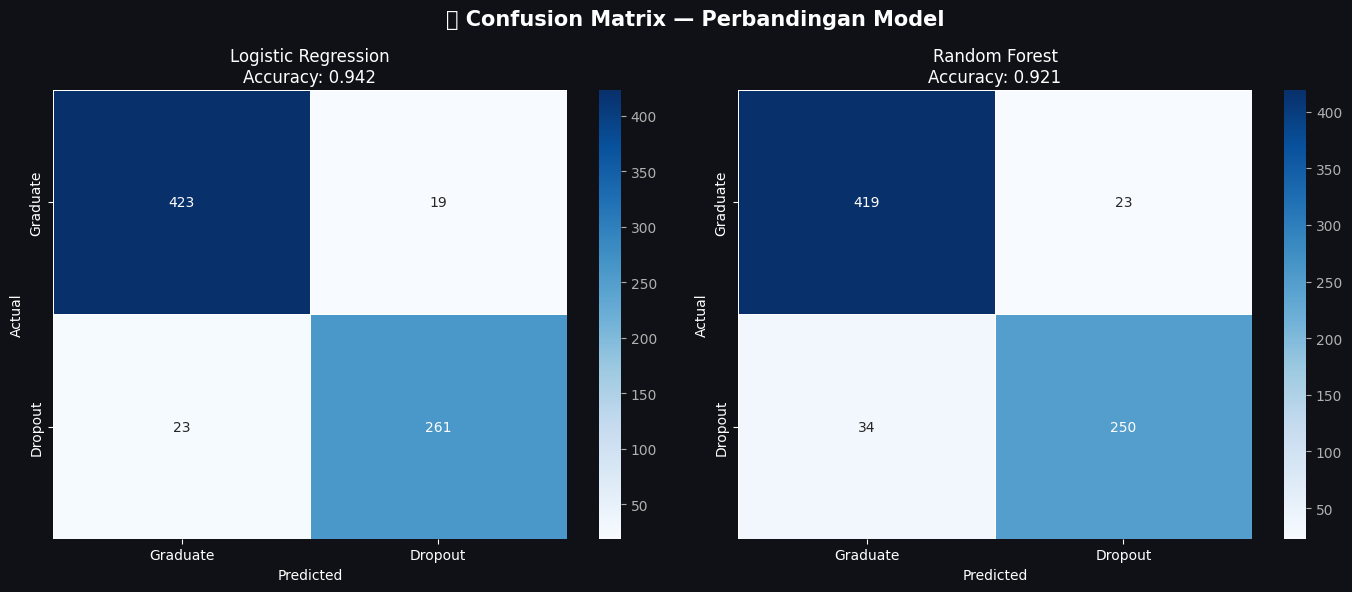

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('🔲 Confusion Matrix — Perbandingan Model',
             fontsize=15, fontweight='bold', color='white')

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_lr, y_pred_rf],
    ['Logistic Regression', 'Random Forest'],
    ['#60a5fa', '#4ade80']
):
    ax.set_facecolor(CARD_BG)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Graduate', 'Dropout'],
                yticklabels=['Graduate', 'Dropout'],
                ax=ax, linewidths=0.5)
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, y_pred):.3f}',
                 color='white', fontsize=12)
    ax.set_xlabel('Predicted', color='white')
    ax.set_ylabel('Actual', color='white')
    ax.tick_params(colors='white')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

### Analisis Confusion Matrix

Dari visualisasi confusion matrix, Logistic Regression tampil lebih
konsisten dibanding Random Forest:

- LR salah mengklasifikasikan lebih sedikit kasus Dropout sebagai Graduate
  (false negative lebih rendah)
- Dalam konteks bisnis, *false negative* (dropout tidak terdeteksi) lebih
  merugikan dibanding *false positive*, sehingga recall yang lebih tinggi
  dari LR menjadi keunggulan nyata
"""

#   ROC Curve

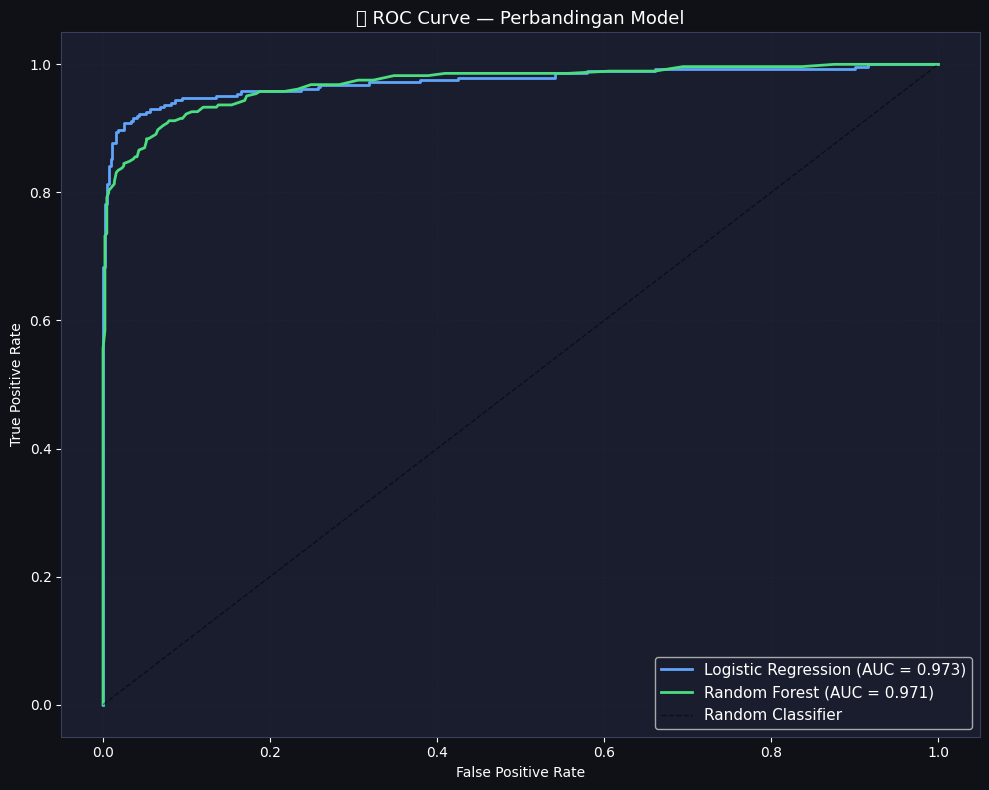

In [52]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr.predict_proba(X_test_sc)[:,1])
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf.predict_proba(X_test)[:,1])

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(CARD_BG)

ax.plot(fpr_lr, tpr_lr, color='#60a5fa', lw=2,
        label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot(fpr_rf, tpr_rf, color='#4ade80', lw=2,
        label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0,1],[0,1], 'k--', lw=1, alpha=0.5, label='Random Classifier')

ax.set_xlabel('False Positive Rate', color='white')
ax.set_ylabel('True Positive Rate', color='white')
ax.set_title('📈 ROC Curve — Perbandingan Model', color='white', fontsize=13)
ax.legend(facecolor=CARD_BG, labelcolor='white', fontsize=11)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#3a3f5c')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

### Analisis ROC Curve

Kedua model menunjukkan kurva ROC yang sangat mendekati sudut kiri atas,
menandakan kemampuan diskriminasi yang sangat baik:

- **Logistic Regression**: AUC = 0.9733
- **Random Forest**: AUC = 0.9706

Selisih AUC antara keduanya sangat kecil (0.0027), namun Logistic
Regression konsisten unggul. Kedua model jauh di atas garis diagonal
(random classifier), membuktikan bahwa faktor akademik dan finansial
yang digunakan benar-benar prediktif untuk status akhir mahasiswa.
"""

#  Feature Importance

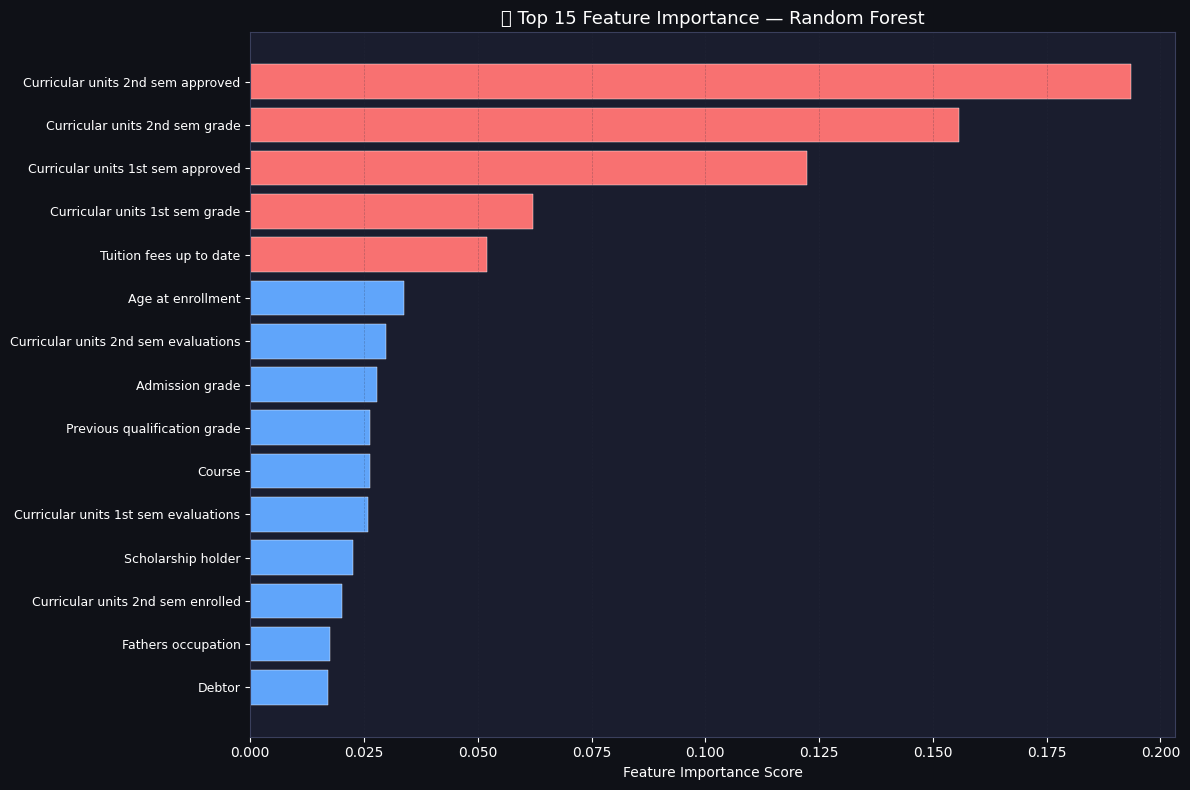


Top 10 Feature Importance:
  Curricular_units_2nd_sem_approved: 0.1935
  Curricular_units_2nd_sem_grade: 0.1558
  Curricular_units_1st_sem_approved: 0.1223
  Curricular_units_1st_sem_grade: 0.0621
  Tuition_fees_up_to_date: 0.0520
  Age_at_enrollment: 0.0338
  Curricular_units_2nd_sem_evaluations: 0.0299
  Admission_grade: 0.0278
  Previous_qualification_grade: 0.0264
  Course: 0.0262


In [53]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_DARK)
ax.set_facecolor(CARD_BG)

top_features = feat_imp.head(15)
colors_bar = ['#f87171' if i < 5 else '#60a5fa' for i in range(len(top_features))]
bars = ax.barh(range(len(top_features)), top_features.values[::-1],
               color=colors_bar[::-1], edgecolor='white', linewidth=0.3)

ax.set_yticks(range(len(top_features)))
ax.set_yticklabels([f.replace('_', ' ') for f in top_features.index[::-1]],
                   color='white', fontsize=9)
ax.set_xlabel('Feature Importance Score', color='white')
ax.set_title('🏆 Top 15 Feature Importance — Random Forest',
             color='white', fontsize=13)
ax.tick_params(colors='white')
for spine in ax.spines.values():
    spine.set_color('#3a3f5c')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

print('\nTop 10 Feature Importance:')
for feat, val in feat_imp.head(10).items():
    print(f'  {feat}: {val:.4f}')

Random Forest mengidentifikasi lima fitur paling berpengaruh dalam
memprediksi dropout:

1. **SKS Lulus Semester 2** (0.194) — faktor paling dominan. Mahasiswa
   yang tidak lulus SKS di semester 2 hampir pasti dropout.
2. **Nilai Rata-rata Semester 2** (0.156) — performa akademik di semester
   akhir mencerminkan kondisi mahasiswa paling terkini.
3. **SKS Lulus Semester 1** (0.122) — sinyal awal yang bisa dideteksi
   lebih cepat.
4. **Nilai Rata-rata Semester 1** (0.062) — performa awal sudah memberi
   gambaran trajektori akademik ke depan.
5. **Status Pembayaran SPP** (0.052) — faktor finansial dengan dampak
   langsung terhadap keberlangsungan studi.

Fakta bahwa 4 dari 5 fitur teratas adalah performa akademik menegaskan
bahwa **deteksi dini melalui monitoring nilai dan SKS adalah prioritas
utama** dalam sistem early warning ini.
"""

# Hyperparameter Tuning

In [54]:
print('\n' + '='*50)
print('HYPERPARAMETER TUNING')
print('='*50)

# Tuning Logistic Regression
print('\n🔍 Tuning Logistic Regression...')
lr_params = {
    'C'        : [0.01, 0.1, 1, 10],
    'solver'   : ['lbfgs', 'liblinear'],
    'max_iter' : [500, 1000]
}
lr_grid = GridSearchCV(LogisticRegression(random_state=42),
                       lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_sc, y_train)
lr_best = lr_grid.best_estimator_
print(f'Best params LR: {lr_grid.best_params_}')
print(f'Best AUC CV   : {lr_grid.best_score_:.4f}')

y_pred_lr_t = lr_best.predict(X_test_sc)
acc_lr_t  = accuracy_score(y_test, y_pred_lr_t)
f1_lr_t   = f1_score(y_test, y_pred_lr_t)
auc_lr_t  = roc_auc_score(y_test, lr_best.predict_proba(X_test_sc)[:,1])
print(f'LR Tuned → Accuracy: {acc_lr_t:.4f} | F1: {f1_lr_t:.4f} | AUC: {auc_lr_t:.4f}')

# Tuning Random Forest
print('\n🌲 Tuning Random Forest...')
rf_params = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42),
                       rf_params, cv=5, scoring='roc_auc', n_jobs=-1)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print(f'Best params RF: {rf_grid.best_params_}')
print(f'Best AUC CV   : {rf_grid.best_score_:.4f}')

y_pred_rf_t = rf_best.predict(X_test)
acc_rf_t  = accuracy_score(y_test, y_pred_rf_t)
f1_rf_t   = f1_score(y_test, y_pred_rf_t)
auc_rf_t  = roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1])
print(f'RF Tuned → Accuracy: {acc_rf_t:.4f} | F1: {f1_rf_t:.4f} | AUC: {auc_rf_t:.4f}')


HYPERPARAMETER TUNING

🔍 Tuning Logistic Regression...
Best params LR: {'C': 1, 'max_iter': 500, 'solver': 'lbfgs'}
Best AUC CV   : 0.9482
LR Tuned → Accuracy: 0.9421 | F1: 0.9255 | AUC: 0.9733

🌲 Tuning Random Forest...
Best params RF: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best AUC CV   : 0.9449
RF Tuned → Accuracy: 0.9174 | F1: 0.8909 | AUC: 0.9712


### Hasil Hyperparameter Tuning

**Logistic Regression**
Parameter terbaik: C=1, solver='lbfgs', max_iter=500.
Setelah tuning, performa tidak berubah signifikan (AUC tetap 0.9733),
menandakan bahwa model LR baseline sudah hampir optimal untuk dataset ini.

**Random Forest**
Parameter terbaik: max_depth=10, min_samples_split=5, n_estimators=200.
Setelah tuning, AUC sedikit meningkat dari 0.9706 menjadi 0.9712, namun
accuracy dan F1 justru sedikit turun (0.917 dan 0.891).

Tuning tidak mengubah kesimpulan: Logistic Regression tetap unggul
di semua metrik utama.
"""

#  Perbandingan Semua Model


=== Perbandingan Semua Model ===
             Accuracy      F1     AUC
LR Baseline    0.9421  0.9255  0.9733
LR Tuned       0.9421  0.9255  0.9733
RF Baseline    0.9215  0.8977  0.9706
RF Tuned       0.9174  0.8909  0.9712


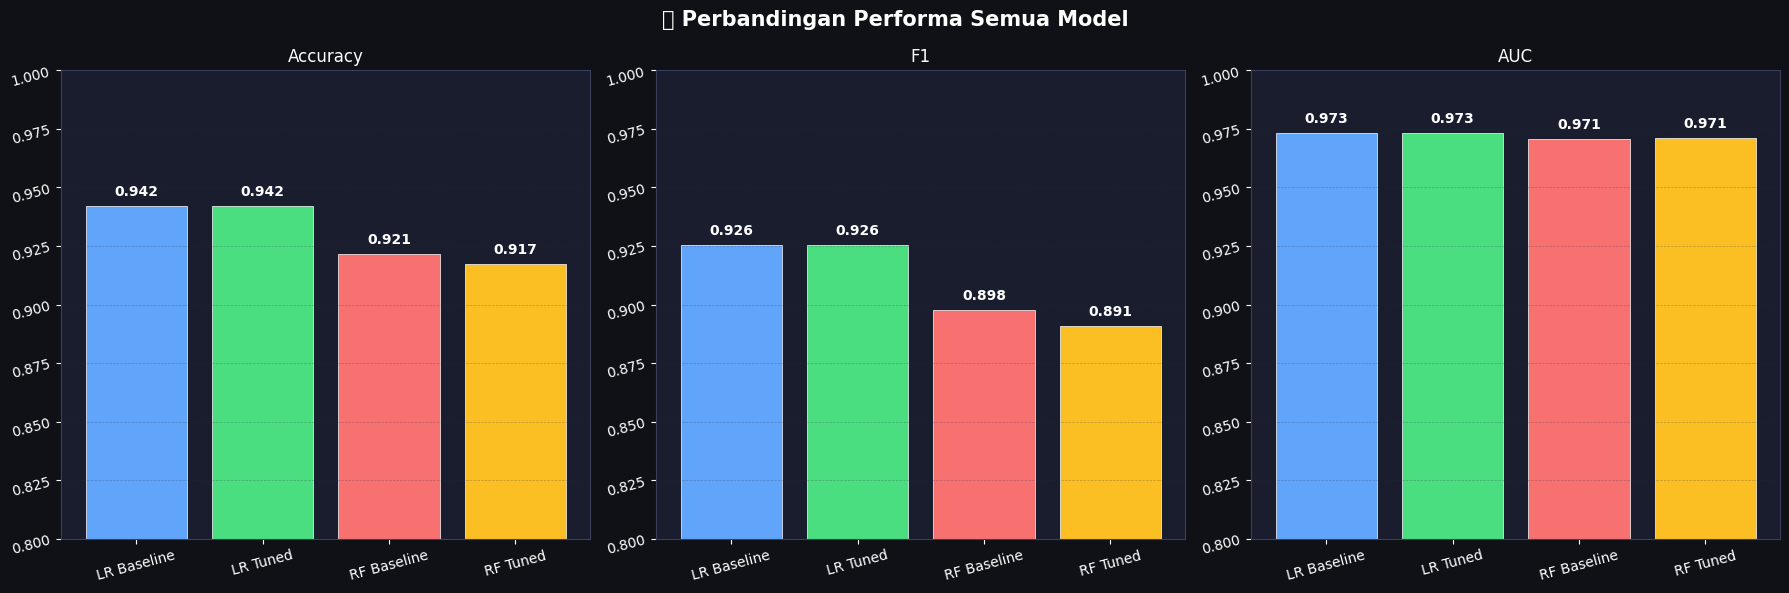

In [55]:
models_compare = {
    'LR Baseline' : {'Accuracy': acc_lr,   'F1': f1_lr,   'AUC': auc_lr},
    'LR Tuned'    : {'Accuracy': acc_lr_t,  'F1': f1_lr_t,  'AUC': auc_lr_t},
    'RF Baseline' : {'Accuracy': acc_rf,   'F1': f1_rf,   'AUC': auc_rf},
    'RF Tuned'    : {'Accuracy': acc_rf_t,  'F1': f1_rf_t,  'AUC': auc_rf_t},
}

df_compare = pd.DataFrame(models_compare).T
print('\n=== Perbandingan Semua Model ===')
print(df_compare.round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('📊 Perbandingan Performa Semua Model',
             fontsize=15, fontweight='bold', color='white')

metrics = ['Accuracy', 'F1', 'AUC']
bar_colors = ['#60a5fa', '#4ade80', '#f87171', '#fbbf24']

for i, metric in enumerate(metrics):
    axes[i].set_facecolor(CARD_BG)
    vals = df_compare[metric]
    bars = axes[i].bar(vals.index, vals.values, color=bar_colors,
                       edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                     f'{val:.3f}', ha='center', va='bottom',
                     color='white', fontsize=10, fontweight='bold')
    axes[i].set_title(metric, color='white', fontsize=12)
    axes[i].set_ylim(0.8, 1.0)
    axes[i].tick_params(colors='white', rotation=15)
    for spine in axes[i].spines.values():
        spine.set_color('#3a3f5c')
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG_DARK)
plt.show()

### Perbandingan Semua Model

| Model | Accuracy | F1 | AUC |
|---|---|---|---|
| LR Baseline | 0.9421 | 0.9255 | 0.9733 |
| LR Tuned | 0.9421 | 0.9255 | 0.9733 |
| RF Baseline | 0.9215 | 0.8977 | 0.9706 |
| RF Tuned | 0.9174 | 0.8909 | 0.9712 |

Logistic Regression (baik baseline maupun tuned) secara konsisten
mengungguli Random Forest di semua metrik. Menariknya, tuning pada LR
tidak mengubah performa sama sekali — ini menunjukkan model sudah
berada di titik optimal dengan konfigurasi default.
"""

#  Pilih Model Terbaik & Simpan

In [56]:
auc_lr_tuned = roc_auc_score(y_test, lr_best.predict_proba(X_test_sc)[:,1])
auc_rf_tuned = roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1])

print(f'\nAUC LR Tuned : {auc_lr_tuned:.4f}')
print(f'AUC RF Tuned : {auc_rf_tuned:.4f}')

if auc_lr_tuned >= auc_rf_tuned:
    best_model  = lr_best
    best_name   = 'Logistic Regression (Tuned)'
    best_scaler = scaler
    uses_scaler = True
    print(f'\n✅ Model terpilih: {best_name}')
else:
    best_model  = rf_best
    best_name   = 'Random Forest (Tuned)'
    best_scaler = None
    uses_scaler = False
    print(f'\n✅ Model terpilih: {best_name}')

# Simpan model
os.makedirs('model', exist_ok=True)
joblib.dump(best_model, 'model/model.pkl')
joblib.dump(scaler,     'model/scaler.pkl')
joblib.dump(list(X.columns), 'model/feature_names.pkl')
print('✅ Model, scaler, dan feature names tersimpan di folder model/')


AUC LR Tuned : 0.9733
AUC RF Tuned : 0.9712

✅ Model terpilih: Logistic Regression (Tuned)
✅ Model, scaler, dan feature names tersimpan di folder model/


### Model Terpilih: Logistic Regression (Tuned)

Berdasarkan perbandingan AUC:
- **LR Tuned: 0.9733**
- RF Tuned: 0.9712

Logistic Regression (Tuned) dipilih sebagai model final karena memiliki
AUC tertinggi sekaligus nilai accuracy dan F1 terbaik. Model beserta
scaler dan daftar fitur telah disimpan di folder `model/` untuk
digunakan pada tahap deployment.
"""


# Inferensi pada Data Enrolled (Optional)

In [57]:
print('\n' + '='*50)
print('INFERENSI — Prediksi Status Akhir Mahasiswa Enrolled')
print('='*50)

# Encode fitur enrolled sama seperti training
X_enrolled = df_enrolled.drop(columns=['Status'])

if uses_scaler:
    X_enrolled_scaled = scaler.transform(X_enrolled)
    pred_enrolled = best_model.predict(X_enrolled_scaled)
    prob_enrolled  = best_model.predict_proba(X_enrolled_scaled)[:,1]
else:
    pred_enrolled = best_model.predict(X_enrolled)
    prob_enrolled  = best_model.predict_proba(X_enrolled)[:,1]

df_enrolled_result = df_enrolled.copy()
df_enrolled_result['Predicted_Status'] = np.where(pred_enrolled == 1, 'Dropout', 'Graduate')
df_enrolled_result['Dropout_Probability'] = prob_enrolled.round(3)

print(f'\nHasil prediksi {len(df_enrolled_result)} mahasiswa Enrolled:')
print(df_enrolled_result['Predicted_Status'].value_counts())
print(f'\nMahasiswa berisiko dropout tinggi (prob > 0.7):')
high_risk = df_enrolled_result[df_enrolled_result['Dropout_Probability'] > 0.7]
print(f'  Jumlah: {len(high_risk)} mahasiswa ({len(high_risk)/len(df_enrolled_result)*100:.1f}%)')

print('\n✅ Inferensi selesai. Data Enrolled telah diprediksi status akhirnya.')


INFERENSI — Prediksi Status Akhir Mahasiswa Enrolled

Hasil prediksi 794 mahasiswa Enrolled:
Predicted_Status
Graduate    430
Dropout     364
Name: count, dtype: int64

Mahasiswa berisiko dropout tinggi (prob > 0.7):
  Jumlah: 251 mahasiswa (31.6%)

✅ Inferensi selesai. Data Enrolled telah diprediksi status akhirnya.


## Inferensi pada Mahasiswa Enrolled

Model digunakan untuk memprediksi kemungkinan status akhir 794 mahasiswa
yang saat ini masih berstatus Enrolled:

- **Graduate**: 430 mahasiswa (54.1%) — diprediksi akan lulus
- **Dropout**: 364 mahasiswa (45.9%) — diprediksi akan dropout

Yang perlu mendapat perhatian khusus: **251 mahasiswa (31.6%)** memiliki
probabilitas dropout di atas 70%. Kelompok inilah yang menjadi prioritas
utama untuk segera mendapat intervensi dari tim akademik dan konselor.

Hasil prediksi ini bersifat indikatif dan dapat digunakan sebagai dasar
penyusunan daftar mahasiswa berisiko tinggi untuk program pendampingan.
"""

## Evaluation

In [58]:
print('\n' + '='*60)
print('EVALUASI FINAL MODEL TERPILIH')
print('='*60)

if uses_scaler:
    y_final_pred = best_model.predict(X_test_sc)
    y_final_prob = best_model.predict_proba(X_test_sc)[:,1]
else:
    y_final_pred = best_model.predict(X_test)
    y_final_prob = best_model.predict_proba(X_test)[:,1]

print(f'\nModel: {best_name}')
print(f'Dataset: Dropout + Graduate only (Enrolled dieksklusi dari training)')
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')
print()
print(f'Accuracy  : {accuracy_score(y_test, y_final_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_final_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_final_pred):.4f}')
print(f'F1 Score  : {f1_score(y_test, y_final_pred):.4f}')
print(f'AUC-ROC   : {roc_auc_score(y_test, y_final_prob):.4f}')
print()
print(classification_report(y_test, y_final_pred,
                             target_names=['Graduate', 'Dropout']))



EVALUASI FINAL MODEL TERPILIH

Model: Logistic Regression (Tuned)
Dataset: Dropout + Graduate only (Enrolled dieksklusi dari training)
Train size: 2904 | Test size: 726

Accuracy  : 0.9421
Precision : 0.9321
Recall    : 0.9190
F1 Score  : 0.9255
AUC-ROC   : 0.9733

              precision    recall  f1-score   support

    Graduate       0.95      0.96      0.95       442
     Dropout       0.93      0.92      0.93       284

    accuracy                           0.94       726
   macro avg       0.94      0.94      0.94       726
weighted avg       0.94      0.94      0.94       726



"""
### Evaluasi Final Model

Model **Logistic Regression (Tuned)** yang dilatih hanya pada data
Dropout dan Graduate menunjukkan performa yang sangat baik:

- **Accuracy 94.2%** — akurasi keseluruhan yang tinggi
- **Precision 93.2%** — prediksi dropout yang dihasilkan sangat andal
- **Recall 91.9%** — model berhasil menangkap sebagian besar kasus dropout
- **F1 Score 92.5%** — keseimbangan antara precision dan recall terjaga baik
- **AUC 0.9733** — kemampuan diskriminasi model sangat tinggi

Dari classification report:
- Untuk kelas **Graduate**: precision 95%, recall 96% → sangat akurat
- Untuk kelas **Dropout**: precision 93%, recall 92% → sangat baik

Performa ini jauh di atas model sebelumnya (akurasi 76%) yang masih
menyertakan data Enrolled dalam training. Pemisahan data Enrolled terbukti
meningkatkan kualitas model secara signifikan karena target menjadi
lebih jelas: hanya dua kelas dengan label final yang sudah pasti.

Model ini siap digunakan sebagai sistem early warning untuk mendeteksi
mahasiswa berisiko dropout di Jaya Jaya Institut.
"""